In [1]:
# Autoreload
%load_ext autoreload
%autoreload 2

import pygad
from scripts import Optimizer,Character,Chromosome,get_item_set
import json
with open('data/MAPPED_ITEMS.json', 'r') as file:
    items = {i["ankama_id"]: i for i in json.load(file)}

with open('data/MAPPED_SETS.json', 'r') as file:
    item_sets = {i["ankama_id"]: i for i in json.load(file)}

In [2]:
config = {
            "optimizer" : {
                "language": "es",
                "population_size": 300,
                "num_parents_mating": 100, # Number of parents to mate, usually 30%
                "num_generations": 500,
                "mutation_rate": 0.05,
                "crossover_rate": 0.8,
                "parent_selection_type": "tournament",  # Tournament Selection
                "tournament_size": 3,
                "exclusions": {
                    "items": [6894,
                              6895,
                              3080,
                              9031,
                              6980 # Vulbis
                              ]  # Excluded items
                },
                "preferences": {
                    "lower": {
                        12: 12,  # AP
                        8: 5,   # MP
                        29: 75,   # Crit
                        28 : 4, # Summons
                    },
                    "upper": {} 
                },
                "level_offset": 10,  # Level offset for items
            },
            "character": {
                "level": 200,
                "scrolled": True,
                "exo": {12:1, # Exo AP
                        8:1}  # Exo MP
            },
        }
config["language"] = config["optimizer"]["language"]

In [3]:
import pandas as pd

effect_descriptions = {}
for _,item in items.items():
    if not item["effects"]:
        continue
    for effect in item["effects"]:
        effect_descriptions[effect["element_id"]] = effect["type"]

dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["language"]],
        "set" : item_set["name"][config["language"]] if item_set else None,
    }
Items = pd.DataFrame.from_dict(dct, orient='index')

In [4]:
char = Character(**config["character"])
opt = Optimizer(char, items, item_sets, **config["optimizer"])

Total pools: 16 with sizes [69, 118, 71, 71, 62, 81, 40, 88, 69, 145, 326, 326, 326, 326, 326, 326]
Total combinations: 10^33.94


In [5]:
opt.optimize()

In [6]:
(opt.solution.fitness, opt.solution.get_damage())

(1732.46, 1732.46)

In [7]:
opt.solution.totals_summary(effect_descriptions,
                      language=config["language"])#.sort_values("value",ascending=False)

,description,value
0,Intercambiable:,0.0
8,PM,6.0
9,vitalidad,2515.0
10,sabiduría,425.0
12,PA,12.0
13,inteligencia,400.0
15,de resistencia a la tierra,10.0
16,% resistencia al aire,13.0
17,% resistencia al agua,28.0
22,suerte,200.0


In [8]:
set_summary = opt.solution.set_summary(language=config["language"])
set_summary

,type_id,type,description,level,set
694,13,Dofus,Dofus Púrpura,110,None
739,13,Dofus,Dofus Turquesa,160,None
7043,13,Dofus,Dofus de los hielos,180,None
7754,13,Dofus,Dofus Ocre,160,None
8993,2,Espada,Espada maldita del gran Desangrador Guerrero,200,None
11728,11,Capa,Capa Icultor,196,Set de apicultor
13344,13,Dofus,Dolmanax,100,None
13642,3,Anillo,Anillo de Noai Aludem,197,Set de Noai Aludem
13643,5,Bota,Getas de Noai Aludem,196,Set de Noai Aludem
14094,1,Amuleto,Amuleto de estrígido,200,Set de estrígido


In [9]:
set_summary["set"].value_counts()

set
Set de Noai Aludem     2
Set de Cocuzko         2
Set de apicultor       1
Set de estrígido       1
Set de los krobios     1
Set de los poseídos    1
Name: count, dtype: int64

Text(0, 0.5, 'Best Fitness')

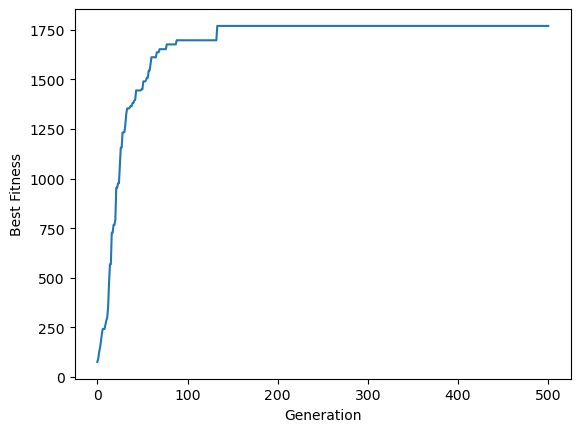

In [10]:
import matplotlib.pyplot as plt
plt.plot(opt.ga_instance.best_solutions_fitness)
plt.xlabel('Generation')
plt.ylabel('Best Fitness')

In [11]:
assert False

AssertionError: 